# PINN-Based Option Pricing with Real Market Data

This notebook applies **Physics-Informed Neural Networks (PINNs)** to solve the Black-Scholes PDE for European call option pricing.

**Key Upgrade:** Instead of fabricated uniform random data, all collocation points (stock prices `S` and volatilities `σ`) are derived from **real NSE stock return data** (`dataset_returns.csv`), covering 50 Indian stocks from 2008–2024.

### Data Pipeline:
1. Load daily log returns for 50 NSE stocks
2. Reconstruct **normalized price paths** (S) via cumulative product
3. Compute **rolling 252-day annualized volatility** (σ) for each stock/day
4. Scale S into the PINN domain [0, S_max] and use σ directly as the volatility input
5. Sample collocation and boundary points from this real (S, σ) distribution

## Cell 1 — Load & Preprocess Real Market Data

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# LOAD REAL MARKET DATA
# ============================================================
# The CSV contains daily returns for 50 NSE stocks (2008–2024).
# Each column is one stock; each row is one trading day.

DATA_PATH = "dataset_returns.csv"   # <-- adjust path if needed

df_returns = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date")
print(f"Loaded {len(df_returns)} trading days × {df_returns.shape[1]} stocks")
print(f"Date range : {df_returns.index[0].date()} → {df_returns.index[-1].date()}")
print(f"Stocks     : {df_returns.columns.tolist()[:5]} … (and {df_returns.shape[1]-5} more)")

# ============================================================
# RECONSTRUCT PRICE PATHS  (normalised so each stock starts = 1)
# ============================================================
# r_t = (P_t - P_{t-1}) / P_{t-1}  => P_t = P_0 * prod(1 + r_i)
price_paths = (1 + df_returns).cumprod()          # shape: (T, 50)

# ============================================================
# ROLLING ANNUALISED VOLATILITY  (252-day window)
# ============================================================
TRADING_DAYS = 252
rolling_vol = df_returns.rolling(TRADING_DAYS).std() * np.sqrt(TRADING_DAYS)
rolling_vol = rolling_vol.dropna()                # drop the first 252 warm-up rows

# Align price paths to the same index
price_aligned = price_paths.loc[rolling_vol.index]

# Flatten: each (day, stock) pair becomes one data point
S_raw    = price_aligned.values.flatten()          # (T*50,)
sig_raw  = rolling_vol.values.flatten()            # (T*50,)

# Remove NaN / inf / extreme outliers
valid = np.isfinite(S_raw) & np.isfinite(sig_raw) & (sig_raw > 0.01) & (sig_raw < 1.5)
S_raw, sig_raw = S_raw[valid], sig_raw[valid]
print(f"\nValid (S, σ) pairs after cleaning : {len(S_raw):,}")
print(f"S    range : [{S_raw.min():.4f}, {S_raw.max():.4f}]")
print(f"σ    range : [{sig_raw.min():.4f}, {sig_raw.max():.4f}]")

# ============================================================
# SCALE S INTO THE PINN DOMAIN  [0, S_max]
# ============================================================
# The Black-Scholes PINN is trained over S in [0, S_max].
# We normalise the real price paths to this same domain so the
# physics boundary conditions remain well-defined.
S_max_data = np.percentile(S_raw, 99)              # robust max (ignore outliers)
S_max      = 3.0                                   # PINN domain upper bound
S_scaled   = np.clip(S_raw / S_max_data * S_max, 0.0, S_max)

print(f"\nScaled S range : [{S_scaled.min():.4f}, {S_scaled.max():.4f}]  (domain [0, {S_max}])")

Loaded 4185 trading days × 50 stocks
Date range : 2008-01-02 → 2024-12-30
Stocks     : ['HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS', 'SBIN.NS', 'AXISBANK.NS'] … (and 45 more)

Valid (S, σ) pairs after cleaning : 196,459
S    range : [0.0007, 143.5476]
σ    range : [0.1326, 1.4054]

Scaled S range : [0.0000, 3.0000]  (domain [0, 3.0])


## Cell 2 — Financial Parameters & Collocation / Boundary Points (Real Data)

In [2]:
# ============================================================
# STEP 1: Financial Parameters
# ============================================================
r   = 0.05    # Risk-free rate (5 %)
K   = 1.0     # Strike price  (in normalised units)
T   = 1.0     # Time to expiry (1 year)

S_min, t_min = 0.0, 0.0
t_max = T

# Volatility bounds observed in real data (clipped)
sigma_min = float(sig_raw.min())
sigma_max = float(np.percentile(sig_raw, 99))      # 99th percentile cap
print(f"Volatility domain : [{sigma_min:.3f}, {sigma_max:.3f}]")

# Number of collocation / boundary points
N_interior = 10000
N_boundary = 2000

# ============================================================
# STEP 2: Sample INTERIOR Collocation Points from REAL DATA
# ============================================================
# Draw random indices from the cleaned (S, σ) pairs.
# Time (t) is sampled uniformly — the PDE must hold at all t.

idx_int = np.random.choice(len(S_scaled), size=N_interior, replace=True)
S_interior     = torch.tensor(S_scaled[idx_int],  dtype=torch.float32).unsqueeze(1)
sigma_interior = torch.tensor(sig_raw[idx_int],   dtype=torch.float32).unsqueeze(1)
# Clip sigma to observed domain
sigma_interior = sigma_interior.clamp(sigma_min, sigma_max)

t_interior = torch.empty(N_interior, 1).uniform_(t_min, t_max)

# CRITICAL: enable autograd for PDE residual computation
S_interior.requires_grad     = True
t_interior.requires_grad     = True

print(f"Interior points — S  : mean={S_interior.mean():.3f}, std={S_interior.std():.3f}")
print(f"Interior points — σ  : mean={sigma_interior.mean():.3f}, std={sigma_interior.std():.3f}")

# ============================================================
# STEP 3: Sample BOUNDARY Points (also drawing σ from real data)
# ============================================================
idx_bnd = np.random.choice(len(sig_raw), size=N_boundary, replace=True)
sig_bnd  = np.clip(sig_raw[idx_bnd], sigma_min, sigma_max)
sig_bnd_t = torch.tensor(sig_bnd, dtype=torch.float32).unsqueeze(1)

# A) Terminal Condition  (t = T)  —  payoff = max(S - K, 0)
S_terminal     = torch.empty(N_boundary, 1).uniform_(S_min, S_max)
t_terminal     = torch.full((N_boundary, 1), T)
sigma_terminal = sig_bnd_t.clone()
V_terminal     = torch.clamp(S_terminal - K, min=0.0)

# B) Lower Boundary  (S = 0)  —  option is worthless
S_zero      = torch.zeros(N_boundary, 1)
t_zero      = torch.empty(N_boundary, 1).uniform_(t_min, t_max)
idx_bnd2    = np.random.choice(len(sig_raw), size=N_boundary, replace=True)
sigma_zero  = torch.tensor(np.clip(sig_raw[idx_bnd2], sigma_min, sigma_max),
                           dtype=torch.float32).unsqueeze(1)
V_zero      = torch.zeros(N_boundary, 1)

# C) Upper Boundary  (S = S_max)  —  deep-in-the-money limit
S_upper     = torch.full((N_boundary, 1), S_max)
t_upper     = torch.empty(N_boundary, 1).uniform_(t_min, t_max)
idx_bnd3    = np.random.choice(len(sig_raw), size=N_boundary, replace=True)
sigma_upper = torch.tensor(np.clip(sig_raw[idx_bnd3], sigma_min, sigma_max),
                           dtype=torch.float32).unsqueeze(1)
V_upper     = S_upper - K * torch.exp(-r * (T - t_upper))

print("\nBoundary tensors constructed from real volatility distribution ✓")

Volatility domain : [0.133, 0.783]
Interior points — S  : mean=0.288, std=0.447
Interior points — σ  : mean=0.331, std=0.121

Boundary tensors constructed from real volatility distribution ✓


## Cell 3 — Neural Network Architecture

In [3]:
import torch.nn as nn

class BlackScholesPINN(nn.Module):
    """PINN for the Black-Scholes PDE.
    Inputs  : (S, t, σ)  — stock price, time, annualised volatility
    Output  : V(S, t, σ) — European call option price
    """
    def __init__(self, hidden_layers=4, neurons_per_layer=50):
        super().__init__()
        layers = []
        layers += [nn.Linear(3, neurons_per_layer), nn.Tanh()]
        for _ in range(hidden_layers):
            layers += [nn.Linear(neurons_per_layer, neurons_per_layer), nn.Tanh()]
        layers.append(nn.Linear(neurons_per_layer, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.network.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0.0)

    def forward(self, S, t, sigma):
        return self.network(torch.cat([S, t, sigma], dim=1))

model = BlackScholesPINN(hidden_layers=4, neurons_per_layer=50)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

BlackScholesPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
    (10): Linear(in_features=50, out_features=1, bias=True)
  )
)

Total trainable parameters: 10,451


## Cell 4 — Loss Function (PDE + Boundary)

In [4]:
def calculate_loss(model,
                   S_interior, t_interior, sigma_interior,
                   S_terminal, t_terminal, sigma_terminal, V_terminal,
                   S_zero,     t_zero,     sigma_zero,     V_zero,
                   S_upper,    t_upper,    sigma_upper,    V_upper,
                   r):
    mse = nn.MSELoss()

    # ---- Boundary losses ----
    loss_terminal = mse(model(S_terminal, t_terminal, sigma_terminal), V_terminal)
    loss_zero     = mse(model(S_zero,     t_zero,     sigma_zero),     V_zero)
    loss_upper    = mse(model(S_upper,    t_upper,    sigma_upper),    V_upper)
    loss_boundary = loss_terminal + loss_zero + loss_upper

    # ---- PDE residual (Black-Scholes) ----
    V_pred = model(S_interior, t_interior, sigma_interior)

    V_t = torch.autograd.grad(
        V_pred, t_interior,
        grad_outputs=torch.ones_like(V_pred),
        retain_graph=True, create_graph=True)[0]

    V_S = torch.autograd.grad(
        V_pred, S_interior,
        grad_outputs=torch.ones_like(V_pred),
        retain_graph=True, create_graph=True)[0]

    V_SS = torch.autograd.grad(
        V_S, S_interior,
        grad_outputs=torch.ones_like(V_S),
        retain_graph=True, create_graph=True)[0]

    # Black-Scholes PDE residual:
    # dV/dt + 0.5*σ²*S²*(d²V/dS²) + r*S*(dV/dS) - r*V = 0
    residual = (V_t
                + 0.5 * sigma_interior**2 * S_interior**2 * V_SS
                + r * S_interior * V_S
                - r * V_pred)

    loss_pde   = mse(residual, torch.zeros_like(residual))
    total_loss = loss_pde + loss_boundary
    return total_loss, loss_boundary, loss_pde

## Cell 5 — Training (Adam → L-BFGS)

In [5]:
import torch.optim as optim

args = (model,
        S_interior, t_interior, sigma_interior,
        S_terminal, t_terminal, sigma_terminal, V_terminal,
        S_zero,     t_zero,     sigma_zero,     V_zero,
        S_upper,    t_upper,    sigma_upper,    V_upper,
        r)

# ---- Stage 1: Adam ----
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
epochs_adam    = 2500
print("Starting Stage 1: Adam optimisation")

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    total_loss, loss_boundary, loss_pde = calculate_loss(*args)
    total_loss.backward()
    optimizer_adam.step()
    if epoch % 500 == 0:
        print(f"  Adam {epoch:04d} | Total: {total_loss.item():.6f} "
              f"| PDE: {loss_pde.item():.6f} | BC: {loss_boundary.item():.6f}")

print("Adam optimisation complete.\n")

# ---- Stage 2: L-BFGS ----
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=0.1, max_iter=500,
                               tolerance_grad=1e-7, tolerance_change=1e-9,
                               history_size=50)
print("Starting Stage 2: L-BFGS optimisation")
lbfgs_iter = 0

def closure():
    global lbfgs_iter
    optimizer_lbfgs.zero_grad()
    total_loss, loss_boundary, loss_pde = calculate_loss(*args)
    total_loss.backward()
    lbfgs_iter += 1
    if lbfgs_iter % 100 == 0:
        print(f"  L-BFGS {lbfgs_iter:04d} | Total: {total_loss.item():.6f} "
              f"| PDE: {loss_pde.item():.6f}")
    return total_loss

optimizer_lbfgs.step(closure)
print("L-BFGS optimisation complete.")

Starting Stage 1: Adam optimisation
  Adam 0000 | Total: 6.408269 | PDE: 0.055387 | BC: 6.352882
  Adam 0500 | Total: 0.002103 | PDE: 0.000770 | BC: 0.001334
  Adam 1000 | Total: 0.001521 | PDE: 0.000451 | BC: 0.001070
  Adam 1500 | Total: 0.001198 | PDE: 0.000302 | BC: 0.000896
  Adam 2000 | Total: 0.000917 | PDE: 0.000210 | BC: 0.000707
Adam optimisation complete.

Starting Stage 2: L-BFGS optimisation
  L-BFGS 0100 | Total: 0.000285 | PDE: 0.000091
  L-BFGS 0200 | Total: 0.000223 | PDE: 0.000052
  L-BFGS 0300 | Total: 0.000202 | PDE: 0.000046
  L-BFGS 0400 | Total: 0.000179 | PDE: 0.000044
  L-BFGS 0500 | Total: 0.000146 | PDE: 0.000045
L-BFGS optimisation complete.


## Cell 6 — Exact Black-Scholes Formula

In [6]:
def exact_black_scholes(S, t, K, r, sigma, T):
    """Closed-form European call price."""
    tau    = np.maximum(T - t, 1e-10)
    S_safe = np.maximum(S, 1e-10)
    d1     = (np.log(S_safe / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2     = d1 - sigma * np.sqrt(tau)
    price  = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    price  = np.where(S == 0, 0.0, price)
    return np.where(t == T, np.maximum(S - K, 0), price)

print("exact_black_scholes() defined ✓")

exact_black_scholes() defined ✓


## Cell 7.1 and 7.2 — 3D Surface & Error Heatmap at Real Volatility

Evaluation σ (median of real data): 0.2981 (29.8% annualised)


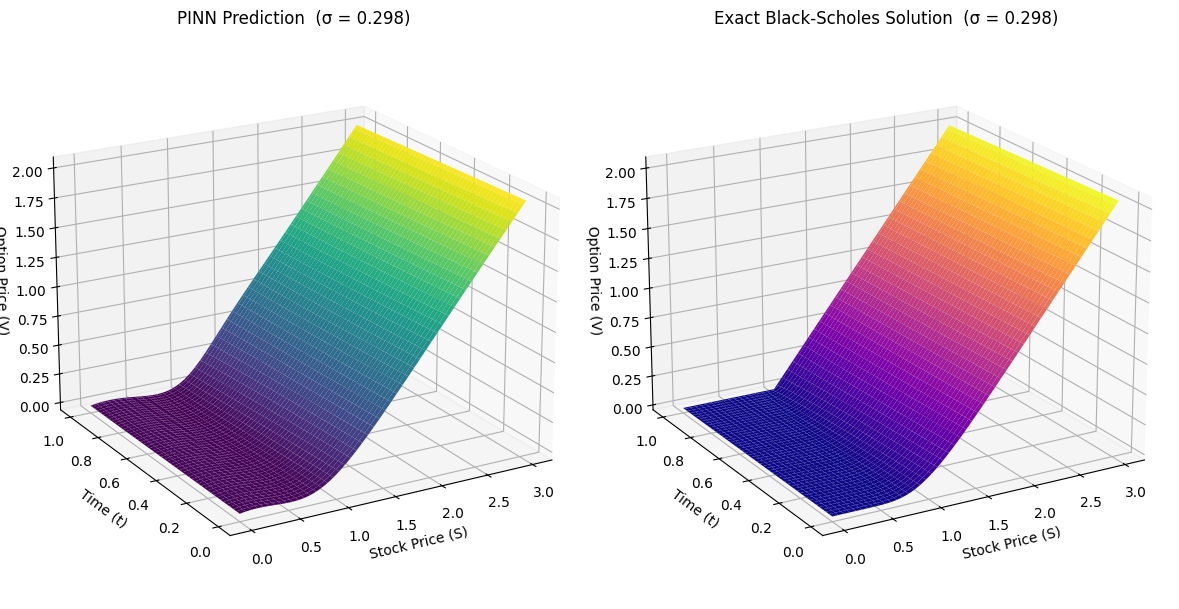

In [15]:
# ============================================================
# Choose a representative volatility from the real data
# (median annualised vol across all stocks)
# ============================================================
sigma_eval = float(np.median(sig_raw))
print(f"Evaluation σ (median of real data): {sigma_eval:.4f} "
      f"({sigma_eval*100:.1f}% annualised)")

S_plot  = np.linspace(0, S_max, 100)
t_plot  = np.linspace(0, T, 100)
S_mesh, t_mesh = np.meshgrid(S_plot, t_plot)

S_flat     = torch.tensor(S_mesh.flatten(), dtype=torch.float32).unsqueeze(1)
t_flat     = torch.tensor(t_mesh.flatten(), dtype=torch.float32).unsqueeze(1)
sigma_flat = torch.full_like(S_flat, sigma_eval)

model.eval()
with torch.no_grad():
    V_pred_flat = model(S_flat, t_flat, sigma_flat).numpy()
V_pred_mesh  = V_pred_flat.reshape(S_mesh.shape)
V_exact_mesh = exact_black_scholes(S_mesh, t_mesh, K, r, sigma_eval, T)

# --- 3D surfaces ---
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(S_mesh, t_mesh, V_pred_mesh,  cmap='viridis', edgecolor='none')
ax1.set_title(f'PINN Prediction  (σ = {sigma_eval:.3f})')
ax1.set_xlabel('Stock Price (S)'); ax1.set_ylabel('Time (t)'); ax1.set_zlabel('Option Price (V)')
ax1.view_init(elev=20, azim=-120)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(S_mesh, t_mesh, V_exact_mesh, cmap='plasma',  edgecolor='none')
ax2.set_title(f'Exact Black-Scholes Solution  (σ = {sigma_eval:.3f})')
ax2.set_xlabel('Stock Price (S)'); ax2.set_ylabel('Time (t)'); ax2.set_zlabel('Option Price (V)')
ax2.view_init(elev=20, azim=-120)
plt.tight_layout(); plt.show()

## --- Error heatmap ---

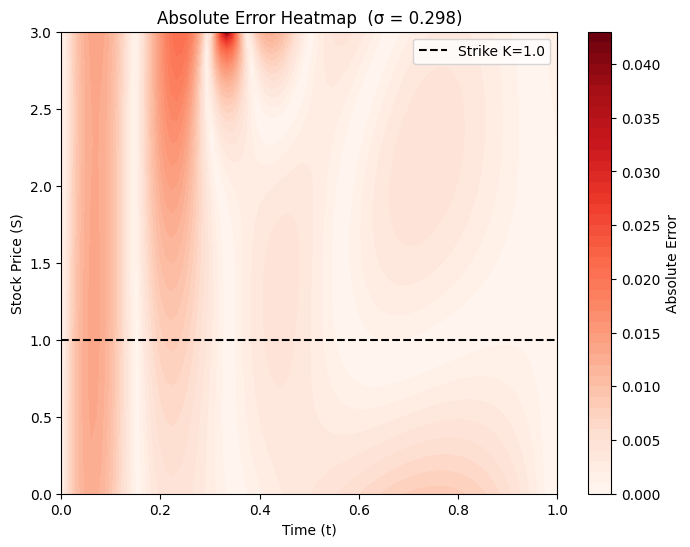

In [17]:
absolute_error = np.abs(V_pred_mesh - V_exact_mesh)
plt.figure(figsize=(8, 6))
contour = plt.contourf(t_mesh, S_mesh, absolute_error.T, levels=50, cmap='Reds')
plt.colorbar(contour, label='Absolute Error')
plt.title(f'Absolute Error Heatmap  (σ = {sigma_eval:.3f})')
plt.xlabel('Time (t)'); plt.ylabel('Stock Price (S)')
plt.axhline(y=K, color='black', linestyle='--', label=f'Strike K={K}')
plt.legend(); plt.show()

## Cell 8 — Time Slices vs Exact Formula

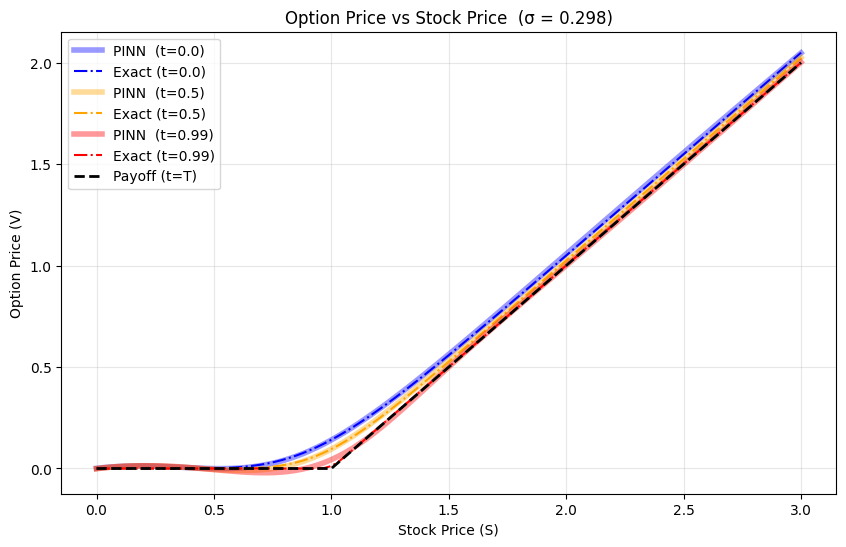

In [8]:
plt.figure(figsize=(10, 6))
time_slices = [0.0, 0.5, 0.99]
colors      = ['blue', 'orange', 'red']

for t_val, col in zip(time_slices, colors):
    S_sl     = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
    t_sl     = torch.full((len(S_plot), 1), t_val)
    sigma_sl = torch.full((len(S_plot), 1), sigma_eval)

    with torch.no_grad():
        V_pred_sl = model(S_sl, t_sl, sigma_sl).numpy().flatten()
    V_exact_sl = exact_black_scholes(S_plot, t_val, K, r, sigma_eval, T)

    plt.plot(S_plot, V_pred_sl,  color=col, linestyle='-',      linewidth=4, alpha=0.4,
             label=f'PINN  (t={t_val})')
    plt.plot(S_plot, V_exact_sl, color=col, linestyle='dashdot', linewidth=1.5,
             label=f'Exact (t={t_val})')

plt.plot(S_plot, np.maximum(S_plot - K, 0), 'k--', linewidth=2, label='Payoff (t=T)')
plt.title(f'Option Price vs Stock Price  (σ = {sigma_eval:.3f})')
plt.xlabel('Stock Price (S)'); plt.ylabel('Option Price (V)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Cell 9 — Delta (Greeks) Computation

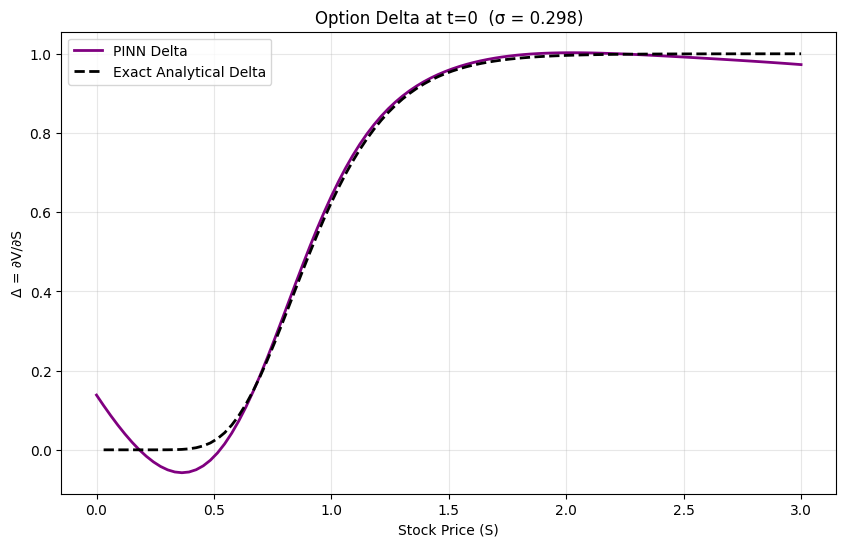

In [9]:
S_tensor = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
S_tensor.requires_grad = True
t_tensor     = torch.zeros(len(S_plot), 1)
sigma_tensor = torch.full((len(S_plot), 1), sigma_eval)

V_tensor = model(S_tensor, t_tensor, sigma_tensor)
Delta_PINN = torch.autograd.grad(
    V_tensor, S_tensor,
    grad_outputs=torch.ones_like(V_tensor)
)[0].detach().numpy().flatten()

# Exact Delta: N(d1) at t=0
S_pos   = S_plot[1:]                 # avoid log(0)
d1_exact = (np.log(S_pos / K) + (r + 0.5 * sigma_eval**2) * T) / (sigma_eval * np.sqrt(T))
Delta_exact = norm.cdf(d1_exact)

plt.figure(figsize=(10, 6))
plt.plot(S_plot,  Delta_PINN,  label='PINN Delta',            color='purple', linewidth=2)
plt.plot(S_pos,   Delta_exact, label='Exact Analytical Delta', color='black',  linestyle='--', linewidth=2)
plt.title(f'Option Delta at t=0  (σ = {sigma_eval:.3f})')
plt.xlabel('Stock Price (S)'); plt.ylabel('Δ = ∂V/∂S')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Cell 10 — Real Volatility Regimes: Pricing Multiple Stocks

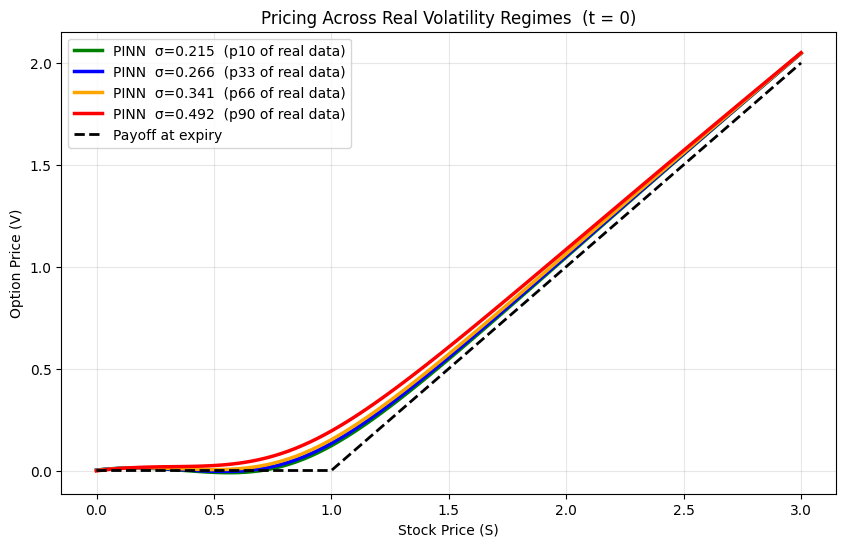


Real-data volatility percentiles used:
  p10: σ = 0.2148  (21.5% annualised)
  p33: σ = 0.2661  (26.6% annualised)
  p66: σ = 0.3408  (34.1% annualised)
  p90: σ = 0.4925  (49.2% annualised)


In [10]:
# ============================================================
# Instead of testing arbitrary σ values, we use actual
# annualised volatilities observed in the dataset:
#   • Percentile 10 (low-vol stable stock)
#   • Percentile 33 (moderate vol)
#   • Percentile 66 (elevated vol)
#   • Percentile 90 (high-vol stock)
# ============================================================
vol_percentiles   = [10, 33, 66, 90]
sigmas_from_data  = [float(np.percentile(sig_raw, p)) for p in vol_percentiles]
colors_sigma      = ['green', 'blue', 'orange', 'red']

plt.figure(figsize=(10, 6))
S_sl = torch.tensor(S_plot, dtype=torch.float32).unsqueeze(1)
t_sl = torch.full((len(S_plot), 1), 0.0)          # today (t = 0)

for sig, col, pct in zip(sigmas_from_data, colors_sigma, vol_percentiles):
    sig_sl = torch.full((len(S_plot), 1), sig)
    with torch.no_grad():
        V_sl = model(S_sl, t_sl, sig_sl).numpy().flatten()
    plt.plot(S_plot, V_sl, color=col, linewidth=2.5,
             label=f'PINN  σ={sig:.3f}  (p{pct} of real data)')

plt.plot(S_plot, np.maximum(S_plot - K, 0), 'k--', linewidth=2, label='Payoff at expiry')
plt.title('Pricing Across Real Volatility Regimes  (t = 0)')
plt.xlabel('Stock Price (S)'); plt.ylabel('Option Price (V)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print("\nReal-data volatility percentiles used:")
for sig, pct in zip(sigmas_from_data, vol_percentiles):
    print(f"  p{pct:2d}: σ = {sig:.4f}  ({sig*100:.1f}% annualised)")

## Cell 11 — Per-Stock Implied Option Price (Real σ for each NSE stock)

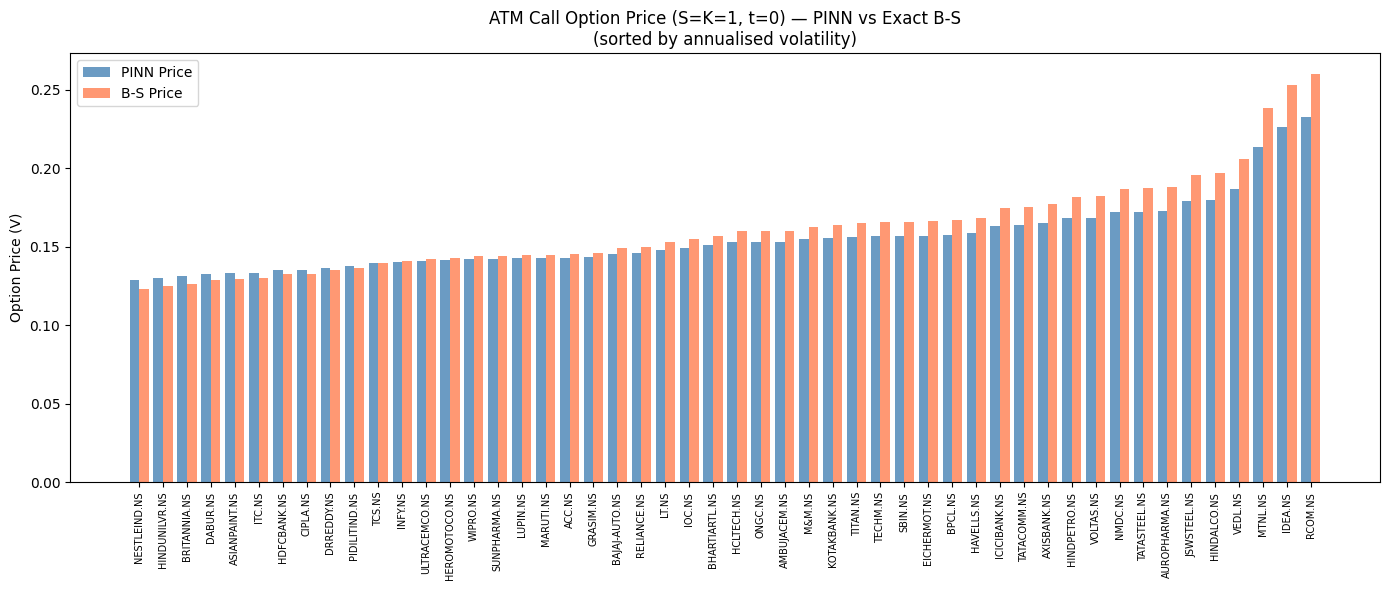


Top-5 highest-vol stocks:
      Stock  Ann_Vol  PINN_Price            BS_Price
HINDALCO.NS 0.443964    0.179603 0.19684136890988985
    VEDL.NS 0.467609    0.186540 0.20575167640834557
    MTNL.NS 0.554088    0.213277 0.23816092691635782
    IDEA.NS 0.594338    0.226410   0.253132504434875
    RCOM.NS 0.613735    0.232886 0.26031837552737913

Top-5 lowest-vol stocks:
        Stock  Ann_Vol  PINN_Price            BS_Price
 NESTLEIND.NS 0.248547    0.129025 0.12281034910262201
HINDUNILVR.NS 0.253983    0.130260 0.12486758432596257
 BRITANNIA.NS 0.258079    0.131197 0.12641833345267495
     DABUR.NS 0.264389    0.132652 0.12880862584158492
ASIANPAINT.NS 0.266484    0.133138 0.12960227519629292


In [11]:
# Compute PINN option price at S=K (at-the-money, t=0) for every stock
# using its full-sample annualised volatility
df_returns_full = pd.read_csv(DATA_PATH, parse_dates=['Date'], index_col='Date')
ann_vols = df_returns_full.std() * np.sqrt(252)

S_atm     = torch.tensor([[K]], dtype=torch.float32)   # ATM: S = K = 1.0
t_now     = torch.tensor([[0.0]], dtype=torch.float32)  # today

records = []
model.eval()
with torch.no_grad():
    for stock, vol in ann_vols.items():
        vol_clipped = float(np.clip(vol, sigma_min, sigma_max))
        sig_t  = torch.tensor([[vol_clipped]], dtype=torch.float32)
        V_pinn = model(S_atm, t_now, sig_t).item()
        V_bs   = exact_black_scholes(K, 0.0, K, r, vol_clipped, T)
        records.append({'Stock': stock, 'Ann_Vol': vol, 'PINN_Price': V_pinn, 'BS_Price': V_bs})

results_df = pd.DataFrame(records).sort_values('Ann_Vol')

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
ax.bar(x - 0.2, results_df['PINN_Price'], width=0.4, label='PINN Price',  alpha=0.8, color='steelblue')
ax.bar(x + 0.2, results_df['BS_Price'],   width=0.4, label='B-S Price',   alpha=0.8, color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Stock'], rotation=90, fontsize=7)
ax.set_title('ATM Call Option Price (S=K=1, t=0) — PINN vs Exact B-S\n(sorted by annualised volatility)')
ax.set_ylabel('Option Price (V)')
ax.legend(); plt.tight_layout(); plt.show()

print("\nTop-5 highest-vol stocks:")
print(results_df.tail(5)[['Stock','Ann_Vol','PINN_Price','BS_Price']].to_string(index=False))
print("\nTop-5 lowest-vol stocks:")
print(results_df.head(5)[['Stock','Ann_Vol','PINN_Price','BS_Price']].to_string(index=False))